# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 25 - 3er bimestre 2026


## **Alumno 1:** Franco Marcelo Morero

Este tercer y último TP se debe entregar hasta las **23:59hs del martes 25 de agosto (hora de Argentina)**.

La resolución del TP se puede hacer en **parejas** o de forma **individual**.

Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/4gQ7iQQyJd2tn4Mb9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERNOMBREALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERNOMBREALUMNO2-TP3-Co25.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP3-Co25.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

In [ ]:
import os
from pathlib import Path

# en local el dataset ya está junto al notebook, en Colab se baja la primera vez.
if not os.path.exists("datos_zip/dataset_emociones/train"):
    %pip install -q gdown
    import gdown
    import zipfile
    gdown.download("https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT", "archivo.zip", quiet=False)
    os.makedirs("datos_zip", exist_ok=True)
    with zipfile.ZipFile("archivo.zip", "r") as zip_ref:
        zip_ref.extractall("datos_zip")
    print("Dataset descargado")


DATASET_ROOT_TRAIN = Path("datos_zip/dataset_emociones/train")
DATASET_ROOT_VAL = Path("datos_zip/dataset_emociones/validation")

assert DATASET_ROOT_TRAIN.exists() and DATASET_ROOT_VAL.exists()
print(f"train      -> {DATASET_ROOT_TRAIN.resolve()}")
print(f"validation -> {DATASET_ROOT_VAL.resolve()}")

train      -> /Users/francomorero/PycharmProjects/franco/ceia-trabajos/aprendizaje_profundo/tps/datos_zip/dataset_emociones/train
validation -> /Users/francomorero/PycharmProjects/franco/ceia-trabajos/aprendizaje_profundo/tps/datos_zip/dataset_emociones/validation


## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



In [4]:
import random

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from PIL import Image

from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")

### Análisis exploratorio

Antes de decidir el preprocesamiento miro cuántas imágenes hay por emoción en cada split. Esto me sirve para verificar que las 7 clases estén presentes tanto en train como en validation, y para detectar desbalanceo, que condiciona decisiones posteriores como la elección de la función de costo y la métrica a optimizar.

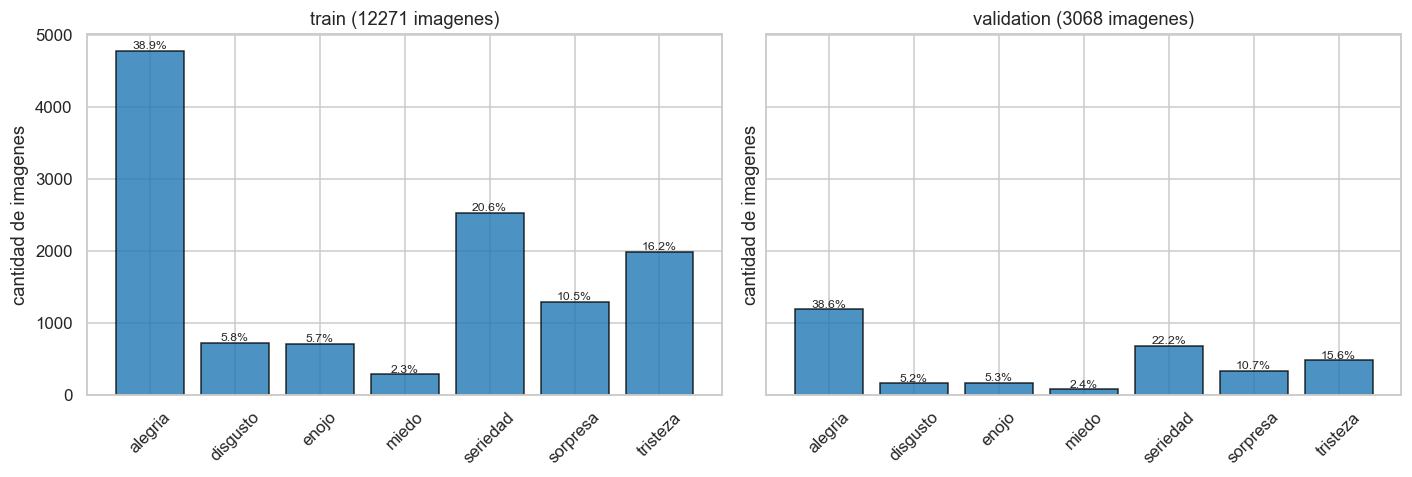

In [5]:
def contar_imagenes(root):
    return {d.name: len(list(d.glob("*.jpg"))) for d in sorted(root.iterdir()) if d.is_dir()}

conteo_train = contar_imagenes(DATASET_ROOT_TRAIN)
conteo_val = contar_imagenes(DATASET_ROOT_VAL)
EMOCIONES = list(conteo_train.keys())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (nombre, conteo) in zip(axes, [("train", conteo_train), ("validation", conteo_val)]):
    total = sum(conteo.values())
    barras = ax.bar(conteo.keys(), conteo.values(), color="tab:blue", edgecolor="black", alpha=0.8)
    for b, cant in zip(barras, conteo.values()):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{cant / total * 100:.1f}%",
                ha="center", va="bottom", fontsize=8)
    ax.set_title(f"{nombre} ({total} imagenes)")
    ax.set_ylabel("cantidad de imagenes")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Observaciones:**

- El dataset está desbalanceado, con más imágenes de alegría que de las demás. Miedo es apenas un 2.3% y alegría es un 38.9%. Enojo y disgusto también tienen poco, apenas un ~5.7% cada una.
- Train y validation comparten la misma distribución (validation es un 20% estratificado de cada clase), así que lo que el modelo vea en entrenamiento es representativo de cómo se lo va a evaluar.
- Con este desbalanceo se podría usar F1 macro, porque por ejemplo con accuracy sola, un modelo que responde siempre alegría ya saca casi 39%.

Ahora miro las imágenes en sí. Tomo 5 ejemplos al azar de cada emoción para entender con qué material estoy trabajando, qué tamaño tienen, si vienen en color y cómo están encuadrados los rostros.

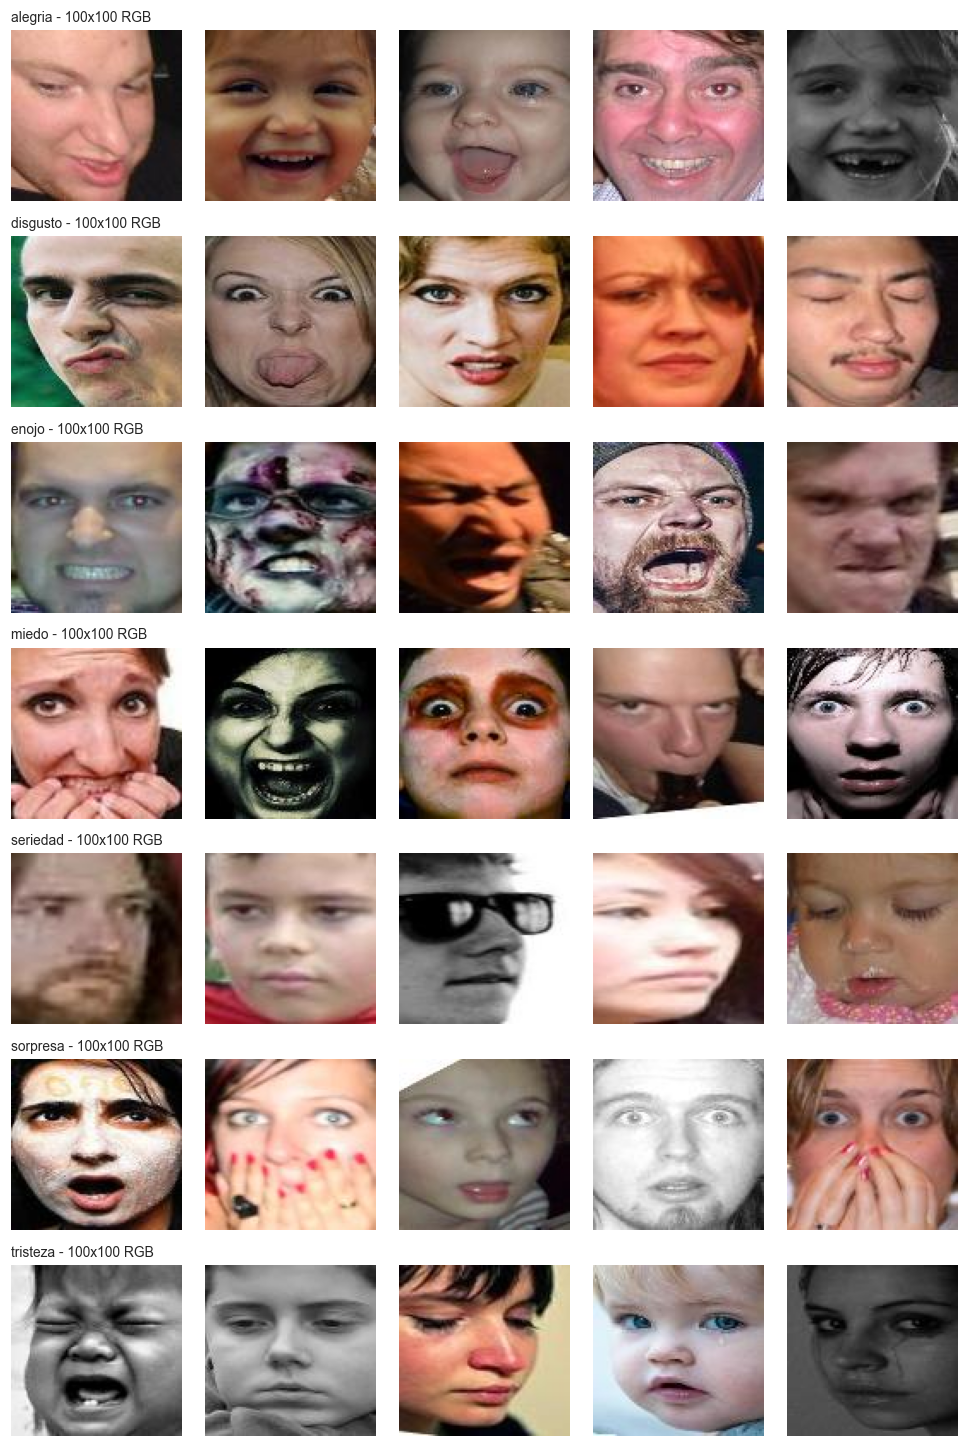

In [6]:
N_MUESTRAS = 5
fig, axes = plt.subplots(len(EMOCIONES), N_MUESTRAS, figsize=(9, 1.9 * len(EMOCIONES)))
for fila, emocion in enumerate(EMOCIONES):
    archivos = random.sample(sorted((DATASET_ROOT_TRAIN / emocion).glob("*.jpg")), N_MUESTRAS)
    for col, archivo in enumerate(archivos):
        img = Image.open(archivo)
        axes[fila, col].imshow(img)
        axes[fila, col].axis("off")
    axes[fila, 0].set_title(f"{emocion} - {img.size[0]}x{img.size[1]} {img.mode}", loc="left", fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
# Chequeo rápido sobre una muestra grande: tamaños, modos y cuántas imágenes tienen color real
muestras = random.sample(sorted(DATASET_ROOT_TRAIN.rglob("*.jpg")), 1000)
tamanos, modos, grises = set(), set(), 0
for ruta in muestras:
    arr = np.array(Image.open(ruta))
    tamanos.add(arr.shape)
    modos.add(Image.open(ruta).mode)
    if arr.ndim == 3 and (arr[..., 0] == arr[..., 1]).all() and (arr[..., 1] == arr[..., 2]).all():
        grises += 1
print(f"formas encontradas      -> {tamanos}")
print(f"modos encontrados       -> {modos}")
print(f"imagenes con color real -> {100 * (1 - grises / len(muestras)):.1f}%")

formas encontradas      -> {(100, 100, 3)}
modos encontrados       -> {'RGB'}
imagenes con color real -> 89.0%


**Observaciones:**

- Todas las imágenes son de 100x100 y ya vienen cuadradas, la relación de aspecto no es un problema y no hace falta recortar ni agregar padding.
- Los rostros vienen alineados y centrados y ocupan casi todo el cuadro, no necesito detección de rostros para entrenar.
- La gran mayoría tiene color real, no son fotos grises guardadas en RGB. En la muestra de 1000 solo un poco más del 10% tiene los tres canales idénticos.

### Elección del preprocesamiento

Con lo que vi arriba defino el pipeline:

- **Color:** Mantengo los 3 canales RGB. La gran mayoría de las imágenes tiene color real y si paso a escala de grises perdería información.
- **Tamaño y relación de aspecto:** Mantengo los 100x100 nativos. Las imágenes ya son cuadradas y uniformes, achicarlas solo perdería detalle. Dejo un resize a 100x100 explícito en el pipeline porque después queremos procesar más imágenes que no estén en este dataset.
- **Escalado a [0, 1]:** Convierto los píxeles de enteros entre 0 y 255 a float32 entre 0 y 1, el rango con el que trabajan cómodas las capas convolucionales y el optimizador.
- **Flip horizontal, solo en train:** Una cara espejada expresa la misma emoción, es el augmentation que aparece en toda la literatura del tema. Ayuda especialmente a las clases chicas como miedo.
- **Rotación de ±10°, solo en train:** Simula pequeñas variaciones de pose y encuadre. La dejo leve a propósito, los rostros ya vienen alineados y una rotación fuerte generaría poses que en validación no existen.

En validation no aplico augmentation porque ahí quiero evaluar siempre sobre las mismas imágenes.

In [8]:
IMG_SIZE = 100
BATCH_SIZE = 64

transform_train = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=10),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

transform_val = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

train_dataset = datasets.ImageFolder(DATASET_ROOT_TRAIN, transform=transform_train)
val_dataset = datasets.ImageFolder(DATASET_ROOT_VAL, transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

CLASES = train_dataset.classes
print(f"clases     -> {CLASES}")
print(f"train      -> {len(train_dataset)} imagenes, {len(train_loader)} batches")
print(f"validation -> {len(val_dataset)} imagenes, {len(val_loader)} batches")

clases     -> ['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza']
train      -> 12271 imagenes, 192 batches
validation -> 3068 imagenes, 48 batches


### Verificación del pipeline

Antes de dar por cerrado el preprocesamiento miro qué le llega efectivamente a la red. Muestro algunas imágenes originales junto a su versión transformada (con el augmentation aplicado, así que alguna puede aparecer espejada o levemente rotada) y chequeo la forma, el tipo y el rango del batch que entrega el DataLoader.

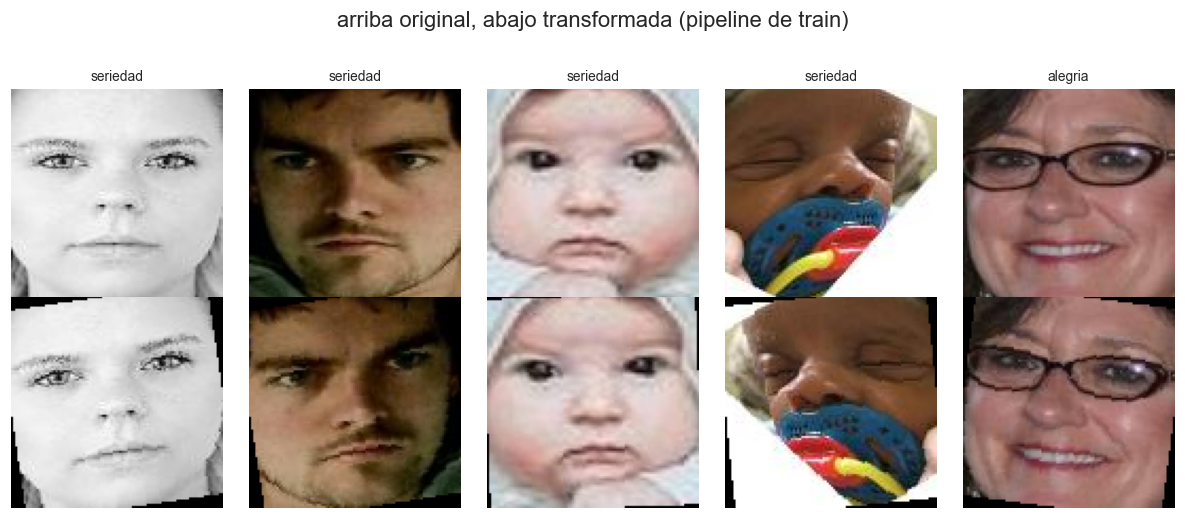

shape del batch -> (64, 3, 100, 100)
dtype           -> torch.float32
rango           -> [0.000, 1.000]


In [9]:
N_EJEMPLOS = 5
indices = random.sample(range(len(train_dataset)), N_EJEMPLOS)

fig, axes = plt.subplots(2, N_EJEMPLOS, figsize=(11, 4.8))
for col, idx in enumerate(indices):
    ruta, etiqueta = train_dataset.samples[idx]
    img_transformada, _ = train_dataset[idx]

    axes[0, col].imshow(Image.open(ruta))
    axes[0, col].set_title(CLASES[etiqueta], fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(img_transformada.permute(1, 2, 0))
    axes[1, col].axis("off")

fig.suptitle("arriba original, abajo transformada (pipeline de train)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

imagenes, etiquetas = next(iter(train_loader))
print(f"shape del batch -> {tuple(imagenes.shape)}")
print(f"dtype           -> {imagenes.dtype}")
print(f"rango           -> [{imagenes.min():.3f}, {imagenes.max():.3f}]")

### Técnicas adoptadas y descartadas

Para tomar mis decisiones revisé tres trabajos sobre reconocimiento de emociones faciales con CNNs:
* [Alizadeh y Fazel, 2017 (Convolutional Neural Networks for Facial Expression Recognition)](https://arxiv.org/abs/1704.06756)
* [Lonkar, 2021 (Facial Expressions Recognition with Convolutional Neural Networks)](https://arxiv.org/abs/2107.08640)
* [Govindwar, Akbani, Wanjari, Nadeshwar, Agashe y Pote, 2024 (Facial Expression Recognition Using Convolutional Neural Network)](https://www.researchgate.net/publication/380241292_Facial_Expression_Recognition_Using_Convolutional_Neural_Network) 

Luego:
- **Augmentation:** Los tres artículos usan flip horizontal. Decido además agregar leves rotaciones para que la red después funcione con fotos donde la cara no esté perfectamente alineada.
- **Desbalanceo:** Utilizo pesos por clase en CrossEntropyLoss, porque los pesos balancean sin tocar la distribución de los datos y son simples de implementar.
- **Normalización con media y desvío:** Decido hacer un escalado simple a [0, 1] como explican en las docs de PyTorch [Getting started with transforms v2](https://docs.pytorch.org/vision/0.28/auto_examples/transforms/plot_transforms_getting_started.html#i-just-want-to-do-image-classification).


Además decido no usar:
- **Flip vertical:** Tener una imagen con una cara dada vuelta sería algo raro para este caso de uso, por lo que considero que no tiene sentido.
- **Distorsiones fuertes o afines:** Una deformación en boca o cejas puede convertir una expresión en otra, es decir cambiarle la etiqueta real a una imagen.

## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

In [10]:
import copy
import time

from sklearn.metrics import accuracy_score, f1_score
from torch import nn

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"device: {device}")

device: mps


### Arquitectura

Para definir la CNN me baso en lo que vi en los papers del punto anterior y en experimentos propios:

- **Cuatro bloques convolucionales:** La imagen entra en 100x100 y cada bloque la reduce a la mitad, hasta llegar a mapas de 6x6. Con menos capas la red se queda corta de capacidad y con más no vi mejora en este problema.
- **Dos convoluciones por bloque:** Probé con una y con dos convoluciones por bloque, y la variante con dos me dio mejores métricas tanto de F1 macro como de accuracy. Lo malo es que tiene casi un 30% más de parámetros y tarda casi el doble de tiempo por época, pero asumo ese costo por las mejoras en los resultados.
- **Kernels de 3x3:** Dos convoluciones de 3x3 seguidas ven la misma zona de la imagen que una de 5x5, pero con menos parámetros y una ReLU extra en el medio.
- **Filtros que se duplican de 32 a 256:** Cada bloque achica el mapa a la mitad y duplica los filtros. Al principio la imagen es grande y con pocos filtros alcanza, al final los mapas son chicos y hacen falta más filtros para representar features complejas.
- **BatchNorm después de cada convolución:** Normaliza las activaciones dentro de la red, lo que estabiliza y acelera el entrenamiento.
- **Dropout:** 0.25 después de cada bloque convolucional y 0.5 en el clasificador fully connected para regularización.
- **Clasificador fully connected de 256 neuronas:** Hago un Flatten y lo paso por una capa fully connected oculta de 256 antes de la capa de salida de 7.

Además uso ReLU para las activaciones en todas las capas ocultas porque es barata de computar.

In [11]:
def bloque_conv(c_in, c_out, p_dropout=0.25):
    # dos Conv-BN-ReLU apiladas antes de cada pooling
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, kernel_size=3, padding=1),
        nn.BatchNorm2d(c_out),
        nn.ReLU(),
        nn.Conv2d(c_out, c_out, kernel_size=3, padding=1),
        nn.BatchNorm2d(c_out),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Dropout2d(p_dropout),
    )


class CNNEmociones(nn.Module):
    def __init__(self, n_clases=len(CLASES), p_dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            bloque_conv(3, 32),     # 100x100 -> 50x50
            bloque_conv(32, 64),    # 50x50 -> 25x25
            bloque_conv(64, 128),   # 25x25 -> 12x12
            bloque_conv(128, 256),  # 12x12 -> 6x6
        )
        self.clasificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p_dropout),
            nn.Linear(256, n_clases),  # logits, la softmax queda dentro de la loss
        )

    def forward(self, x):
        return self.clasificador(self.features(x))

In [15]:
modelo = CNNEmociones().to(device)
print(modelo)

n_params = sum(p.numel() for p in modelo.parameters())
print(f"\nparámetros entrenables: {n_params:,}")

CNNEmociones(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Dropout2d(p=0.25, inplace=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): Re

In [16]:
# Pesos por clase para la función de costo
conteos = np.bincount(train_dataset.targets)
pesos = conteos.sum() / (len(CLASES) * conteos)
pesos_clase = torch.tensor(pesos, dtype=torch.float32, device=device)

for clase, n, w in zip(CLASES, conteos, pesos):
    print(f"{clase:10s} -> {n:5d} imagenes, peso {w:.2f}")

alegria    ->  4772 imagenes, peso 0.37
disgusto   ->   717 imagenes, peso 2.44
enojo      ->   705 imagenes, peso 2.49
miedo      ->   281 imagenes, peso 6.24
seriedad   ->  2524 imagenes, peso 0.69
sorpresa   ->  1290 imagenes, peso 1.36
tristeza   ->  1982 imagenes, peso 0.88


### Entrenamiento

Decisiones:

- **Función de costo:** [CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html), la loss estándar para clasificación multiclase. Recibe los 7 logits crudos, aplica la softmax adentro de forma numéricamente estable, y con el argumento weight le paso los pesos por clase.
- **Optimizador:** Adam, pues adapta el learning rate por parámetro y converge rápido.
- **Learning rate:** 1e-3, el default de Adam, con un scheduler [CosineAnnealingLR](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html) que lo baja gradualmente hasta casi cero. Así el entrenamiento arranca con pasos grandes y termina con pasos chicos que afinan el resultado.
- **Épocas:** Hasta 60 con early stopping, corto si el F1 macro de validación no mejora en 10 épocas seguidas y me quedo con la mejor época.
- **Métricas de train:** Las acumulo durante la misma pasada de entrenamiento para no re-evaluar todo el train en cada época. Son aproximadas porque se calculan con dropout activo, pero alcanzan para seguir la evolución. Las de validación, que deciden el early stopping, sí se calculan exactas en modo eval.

La celda que sigue respeta el flag `RETRAIN` del inicio del notebook. Con True entrena desde cero (~46 min en mps), con False carga el modelo y el historial desde el checkpoint y todo lo demás corre igual. El output que quedó guardado abajo es el del entrenamiento real.

In [17]:
ce_loss = nn.CrossEntropyLoss(weight=pesos_clase)


def entrenar(modelo, lr=1e-3, epocas=60, paciencia=10, verbose=False):
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizador, T_max=epocas)
    hist = {k: [] for k in ["loss_train", "loss_val", "acc_train", "acc_val", "f1_train", "f1_val"]}
    mejor_f1, mejor_estado, sin_mejora = -float("inf"), None, 0
    for epoca in range(1, epocas + 1):
        modelo.train()
        loss_acum, y_true, y_pred = 0.0, [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = modelo(xb)
            loss = ce_loss(logits, yb)
            optimizador.zero_grad(set_to_none=True)
            loss.backward()
            optimizador.step()
            loss_acum += loss.item() * len(yb)
            y_true.append(yb.cpu())
            y_pred.append(logits.argmax(dim=1).cpu())
        scheduler.step()

        y_true = torch.cat(y_true).numpy()
        y_pred = torch.cat(y_pred).numpy()
        loss_tr = loss_acum / len(train_loader.dataset)
        acc_tr = accuracy_score(y_true, y_pred)
        f1_tr = f1_score(y_true, y_pred, average="macro")
        loss_va, acc_va, f1_va, _ = evaluar(modelo, val_loader)
        for k, v in zip(hist, [loss_tr, loss_va, acc_tr, acc_va, f1_tr, f1_va]):
            hist[k].append(v)
        if verbose and (epoca % 5 == 0 or epoca == 1):
            print(f"época {epoca:3d} | loss train {loss_tr:.4f} val {loss_va:.4f} | "
                  f"acc val {acc_va:.4f} | F1 macro val {f1_va:.4f}")

        if f1_va > mejor_f1:
            mejor_f1, sin_mejora = f1_va, 0
            mejor_estado = copy.deepcopy(modelo.state_dict())
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                if verbose:
                    print(f"early stopping en la época {epoca} (mejor F1 macro val: {mejor_f1:.4f})")
                break

    modelo.load_state_dict(mejor_estado)
    return hist


def evaluar(modelo, dl):
    modelo.eval()
    loss_total, y_true, y_pred = 0.0, [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = modelo(xb)
            loss_total += ce_loss(logits, yb).item() * len(yb)
            y_true.append(yb.cpu())
            y_pred.append(logits.argmax(dim=1).cpu())
    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()
    return (loss_total / len(dl.dataset),
            accuracy_score(y_true, y_pred),
            f1_score(y_true, y_pred, average="macro"),
            y_pred)


def modelo_nuevo():
    torch.manual_seed(SEED)
    return CNNEmociones().to(device)

In [ ]:
LR = 1e-3
EPOCAS_MAX = 60
PACIENCIA = 10

inicio = time.perf_counter()
modelo = modelo_nuevo()
hist = entrenar(modelo, LR, EPOCAS_MAX, PACIENCIA, verbose=True)
tiempo_cnn = time.perf_counter() - inicio
epocas_entrenadas = len(hist["loss_val"])
print(f"épocas entrenadas: {epocas_entrenadas}")
print(f"tiempo de entrenamiento: {tiempo_cnn / 60:.1f} min")

época   1 | loss train 1.9531 val 1.8027 | acc val 0.3501 | F1 macro val 0.1832
época   5 | loss train 1.4896 val 1.2649 | acc val 0.5368 | F1 macro val 0.4198
época  10 | loss train 1.1355 val 0.9332 | acc val 0.6701 | F1 macro val 0.5692
época  15 | loss train 0.9568 val 0.8138 | acc val 0.7073 | F1 macro val 0.6138
época  20 | loss train 0.8045 val 0.7255 | acc val 0.7363 | F1 macro val 0.6483
época  25 | loss train 0.6929 val 0.6960 | acc val 0.7503 | F1 macro val 0.6595
época  30 | loss train 0.6056 val 0.6697 | acc val 0.7601 | F1 macro val 0.6730
época  35 | loss train 0.5279 val 0.6370 | acc val 0.7731 | F1 macro val 0.6887
época  40 | loss train 0.4577 val 0.6091 | acc val 0.7832 | F1 macro val 0.7020
época  45 | loss train 0.4025 val 0.6141 | acc val 0.7927 | F1 macro val 0.7125
época  50 | loss train 0.3767 val 0.6092 | acc val 0.7888 | F1 macro val 0.7086
época  55 | loss train 0.3503 val 0.6066 | acc val 0.7917 | F1 macro val 0.7159
época  60 | loss train 0.3512 val 0.5999

In [21]:
mejor_epoca = int(np.argmax(hist["f1_val"])) + 1
print(f"mejor época: {mejor_epoca} | F1 macro val {hist['f1_val'][mejor_epoca - 1]:.4f}")

mejor época: 52 | F1 macro val 0.7181


Guardo los pesos de la mejor época y el historial de métricas junto al notebook, para luego poder usar el modelo con otras fotos, sin esperar el largo tiempo de entrenamiento.

In [ ]:
RUTA_MODELO = Path("Morero-Franco-TP3-modelo.pt")
torch.save({"estado": modelo.state_dict(), "hist": hist}, RUTA_MODELO)
print(f"modelo guardado en {RUTA_MODELO} ({RUTA_MODELO.stat().st_size / 1e6:.1f} MB)")

modelo guardado en Morero-Franco-TP3-modelo.pt (14.2 MB)


## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


### Curvas de loss, accuracy y F1 macro por época

Grafico la evolución de las tres métricas durante el entrenamiento, para train y validación.

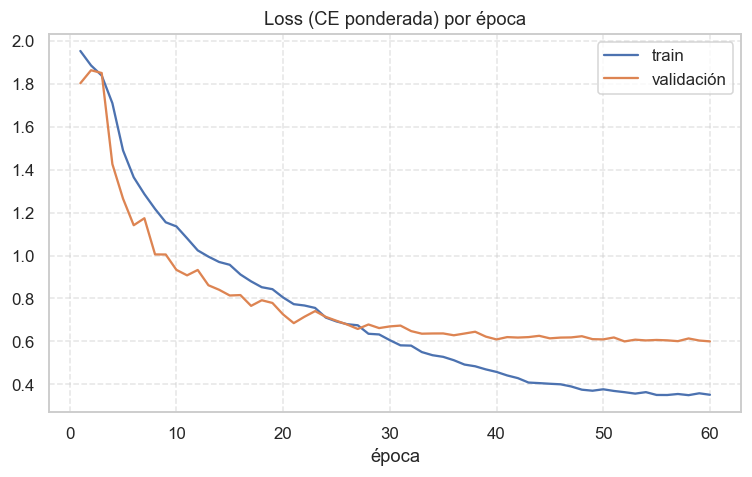

In [15]:
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, epocas_entrenadas + 1), hist["loss_train"], label="train")
plt.plot(range(1, epocas_entrenadas + 1), hist["loss_val"], label="validación")
plt.title("Loss (CE ponderada) por época")
plt.xlabel("época")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

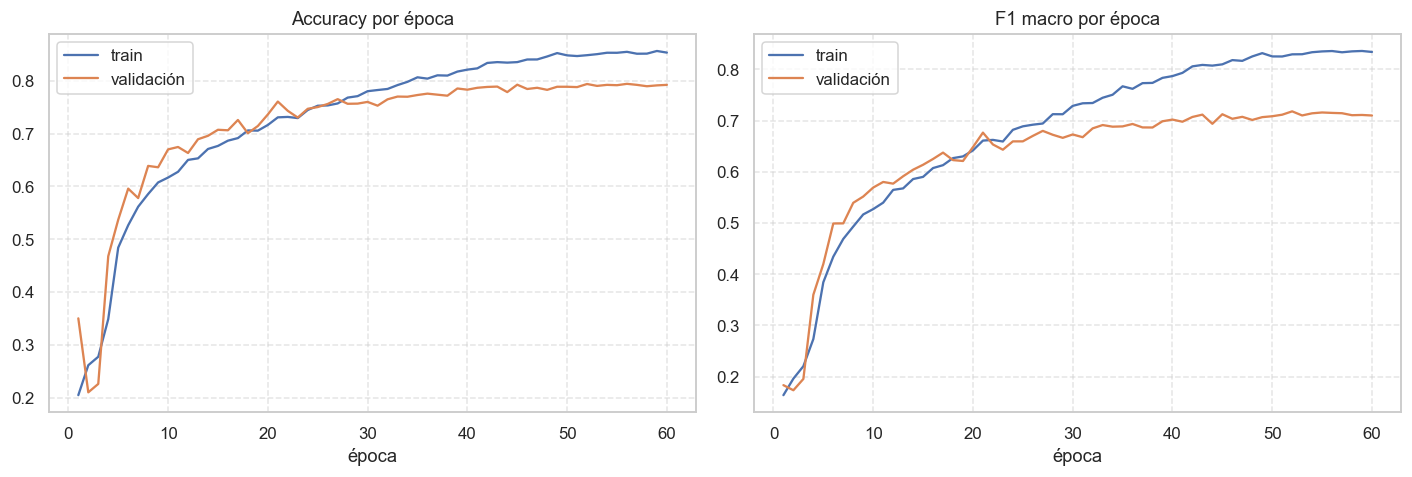

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metrica, titulo in [
    (axes[0], "acc", "Accuracy por época"),
    (axes[1], "f1", "F1 macro por época"),
]:
    ax.plot(range(1, epocas_entrenadas + 1), hist[f"{metrica}_train"], label="train")
    ax.plot(range(1, epocas_entrenadas + 1), hist[f"{metrica}_val"], label="validación")
    ax.set_title(titulo)
    ax.set_xlabel("época")
    ax.grid(True, ls="--", alpha=0.5)
    ax.legend()
plt.tight_layout()
plt.show()

La loss de validación acompaña a la de train hasta pasada la mitad del entrenamiento y de ahí en más se aplana, mientras la de train sigue bajando hasta el final. Hay sobreajuste, pero no mucho. La brecha crece despacio y la loss de validación nunca llega a darse vuelta y subir, en parte por el dropout en cada bloque y en parte porque el scheduler achica los pasos sobre el final y el modelo deja de moverse.

Las curvas de accuracy y F1 macro cuentan lo mismo desde el otro lado, con un detalle que llama la atención al principio, validación arranca por encima de train. Es un efecto de cómo mido, las métricas de train se acumulan durante la misma pasada de entrenamiento con dropout activo y la red cambiando batch a batch, así que dan peor, mientras que las de validación se calculan con el modelo en modo eval. Luego de unas épocas train la pasa y la brecha queda acotada. Validación se estanca y oscila alrededor de su nivel sin caerse, el serrucho época a época es ruido de mini-batches. El early stopping no llegó a cortar antes porque la mejor época quedó cerca del final, y los pesos que guardamos son los de esa época, no los de la última.

El F1 macro de validación queda por debajo de la accuracy durante todo el entrenamiento, esperable con este desbalanceo. La accuracy la sostienen las clases grandes como alegría, mientras que el F1 macro le da el mismo peso a las siete clases y las chicas todavía cuestan.

### Evaluación en validación

Reporto la accuracy y el F1 macro finales sobre el conjunto de validación completo, con el modelo de la mejor época que dejó el early stopping, y el detalle de precisión, recall y F1 por clase con el reporte de clasificación.

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

loss_va, acc_va, f1_va, pred_va = evaluar(modelo, val_loader)
y_va_np = np.array(val_dataset.targets)

print(f"accuracy val {acc_va:.4f} | F1 macro val {f1_va:.4f} | loss val {loss_va:.4f}\n")
print(classification_report(y_va_np, pred_va, target_names=CLASES, digits=4))

accuracy val 0.7940 | F1 macro val 0.7181 | loss val 0.5997

              precision    recall  f1-score   support

     alegria     0.9329    0.8684    0.8995      1185
    disgusto     0.4455    0.5625    0.4972       160
       enojo     0.6833    0.7593    0.7193       162
       miedo     0.5696    0.6081    0.5882        74
    seriedad     0.7806    0.7324    0.7557       680
    sorpresa     0.7863    0.8389    0.8118       329
    tristeza     0.7282    0.7845    0.7553       478

    accuracy                         0.7940      3068
   macro avg     0.7038    0.7363    0.7181      3068
weighted avg     0.8042    0.7940    0.7977      3068



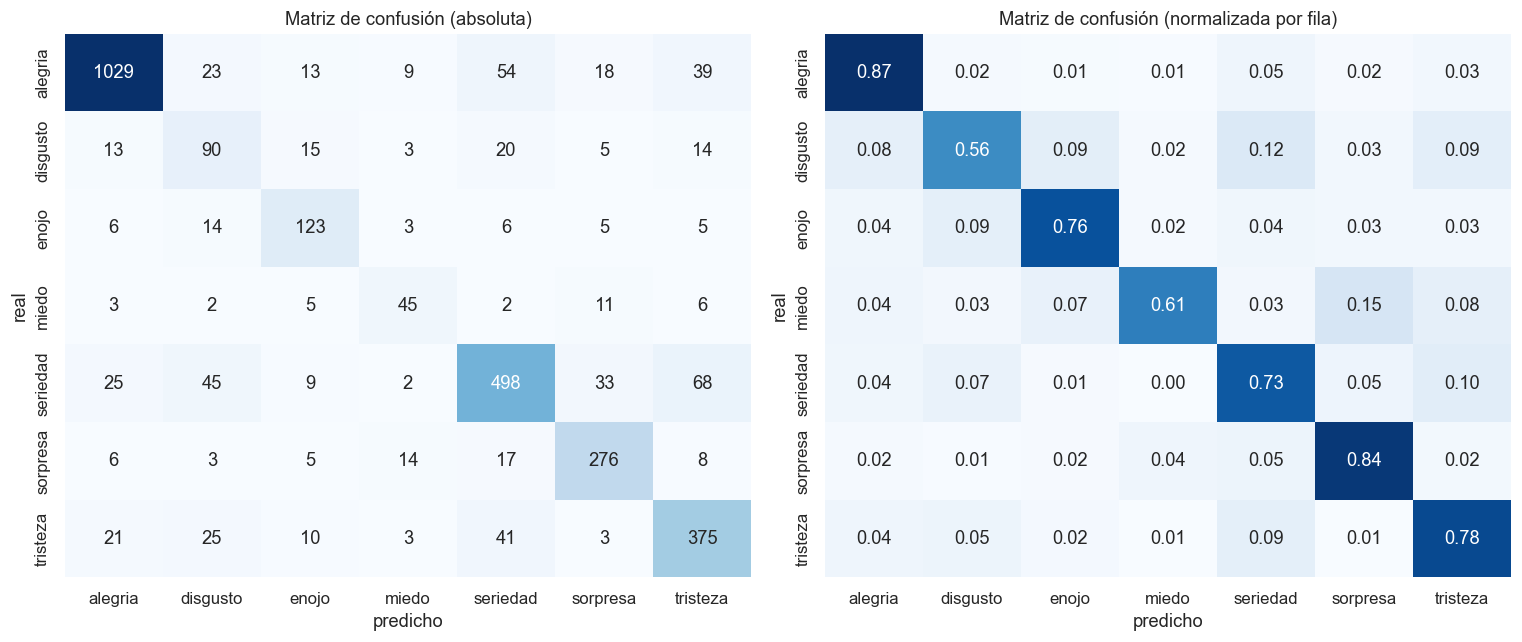

In [18]:
cm_abs = confusion_matrix(y_va_np, pred_va)
cm_norm = confusion_matrix(y_va_np, pred_va, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm, fmt, titulo in [
    (axes[0], cm_abs, "d", "Matriz de confusión (absoluta)"),
    (axes[1], cm_norm, ".2f", "Matriz de confusión (normalizada por fila)"),
]:
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues", cbar=False,
                xticklabels=CLASES, yticklabels=CLASES, ax=ax)
    ax.set_xlabel("predicho")
    ax.set_ylabel("real")
    ax.set_title(titulo)
plt.tight_layout()
plt.show()

Del classification report y las matrices salen dos lecturas:

* La primera es que alegría es por lejos la clase más fácil, con la mejor precisión y el mejor recall del set, y sorpresa viene segunda. Las dos son expresiones visualmente marcadas, una sonrisa o una boca abierta se distinguen bien. En el otro extremo quedan disgusto y miedo, que son justamente las clases con menos imágenes de entrenamiento.

* La segunda lectura es que los pesos por clase funcionaron bien. La matriz normalizada por fila muestra el recall de cada clase, y hasta las clases chicas aciertan bien más de la mitad de sus casos, cuando sin compensar el desbalanceo lo esperado sería que el modelo directamente las ignore a favor de alegría y seriedad. El costo se paga en precisión, el modelo tiende a predecir de más las clases chicas y entonces una parte de lo que marca como disgusto o como miedo en realidad no lo es, por eso en esas clases la precisión queda por debajo del recall.

Algo que me llama la atención es cómo el modelo se confunde entre emociones. Disgusto se confunde con seriedad, enojo y tristeza, miedo se va hacia sorpresa, que comparte los ojos abiertos y la boca tensa, y seriedad y tristeza se mezclan en los dos sentidos, que son las dos expresiones más neutras del dataset. Ninguna clase colapsa sobre otra, el error está repartido, así que no parece haber un sesgo puntual del modelo sino la ambigüedad propia de caras que hasta una persona etiquetaría distinto.

 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

Antes de pasar las fotos por la red restauro siempre el modelo entrenado desde el checkpoint del punto 2. Si el kernel se reinició y se ejecutan las celdas en orden, evitando la celda de entrenar, la variable `modelo` puede quedar apuntando a la red sin entrenar y con esos pesos aleatorios todas las predicciones dan mal.

In [12]:
import pandas as pd

In [18]:
RUTA_MODELO = Path("Morero-Franco-TP3-modelo.pt")

checkpoint = torch.load(RUTA_MODELO, map_location=device, weights_only=False)
modelo = modelo_nuevo()
modelo.load_state_dict(checkpoint["estado"])
hist = checkpoint["hist"]
epocas_entrenadas = len(hist["loss_val"])
print("modelo e historial restaurados desde el checkpoint")

modelo e historial restaurados desde el checkpoint


### Carga y predicción de las fotos nuevas

Armo el set de prueba con 12 fotos sueltas bajadas de internet, con al menos una por emoción. Son fotos de distintos tamaños y relaciones de aspecto, con fondo, torso y encuadres variados, bien distintas a las caras centradas de 100x100 del dataset.

In [19]:
RUTA_IMAGENES = Path("imagenes")


def cargar_imagenes_nuevas(raiz=RUTA_IMAGENES):
    imagenes = []
    for carpeta in sorted(raiz.iterdir()):
        if not carpeta.is_dir():
            continue
        for archivo in sorted(carpeta.glob("*.jpg")):
            imagenes.append((Image.open(archivo).convert("RGB"), carpeta.name, archivo.stem))
    return imagenes


def preprocesar(imagen):
    # mismo pipeline que validation
    return transform_val(imagen)


def predecir_emocion(modelo, tensor):
    modelo.eval()
    with torch.no_grad():
        scores = torch.softmax(modelo(tensor.unsqueeze(0).to(device)), dim=1).squeeze(0).cpu().numpy()
    return scores, CLASES[int(scores.argmax())]


def mostrar_prediccion(fila_axes, paneles, scores, esperada, ganadora):
    # los primeros ejes muestran las imágenes de paneles, el último queda para los scores
    for ax, (titulo, img) in zip(fila_axes, paneles):
        if isinstance(img, torch.Tensor):
            ax.imshow(img.permute(1, 2, 0))
        else:
            ax.imshow(img)
        ax.set_title(titulo, fontsize=9)
        ax.axis("off")
    ax_scores = fila_axes[-1]
    colores = ["tab:green" if clase == ganadora else "tab:blue" for clase in CLASES]
    ax_scores.barh(CLASES, scores * 100, color=colores)
    ax_scores.set_xlim(0, 105)
    ax_scores.invert_yaxis()
    ax_scores.set_title(f"esperada: {esperada} | inferida: {ganadora}", fontsize=9)
    for i, s in enumerate(scores):
        ax_scores.text(min(s * 100 + 1, 88), i, f"{s * 100:.1f}%", va="center", fontsize=7)


imagenes_nuevas = cargar_imagenes_nuevas()
print(f"imagenes cargadas: {len(imagenes_nuevas)}")
for _, esperada, nombre in imagenes_nuevas:
    print(f"{nombre} -> {esperada}")

imagenes cargadas: 12
alegria_01 -> alegria
alegria_02 -> alegria
alegria_03 -> alegria
disgusto_01 -> disgusto
enojo_01 -> enojo
enojo_02 -> enojo
miedo_01 -> miedo
seriedad_01 -> seriedad
seriedad_02 -> seriedad
sorpresa_01 -> sorpresa
tristeza_01 -> tristeza
tristeza_02 -> tristeza


Paso cada foto por el modelo y muestro la original, la pre-procesada con el mismo pipeline de validation y los scores por clase con la ganadora en verde.

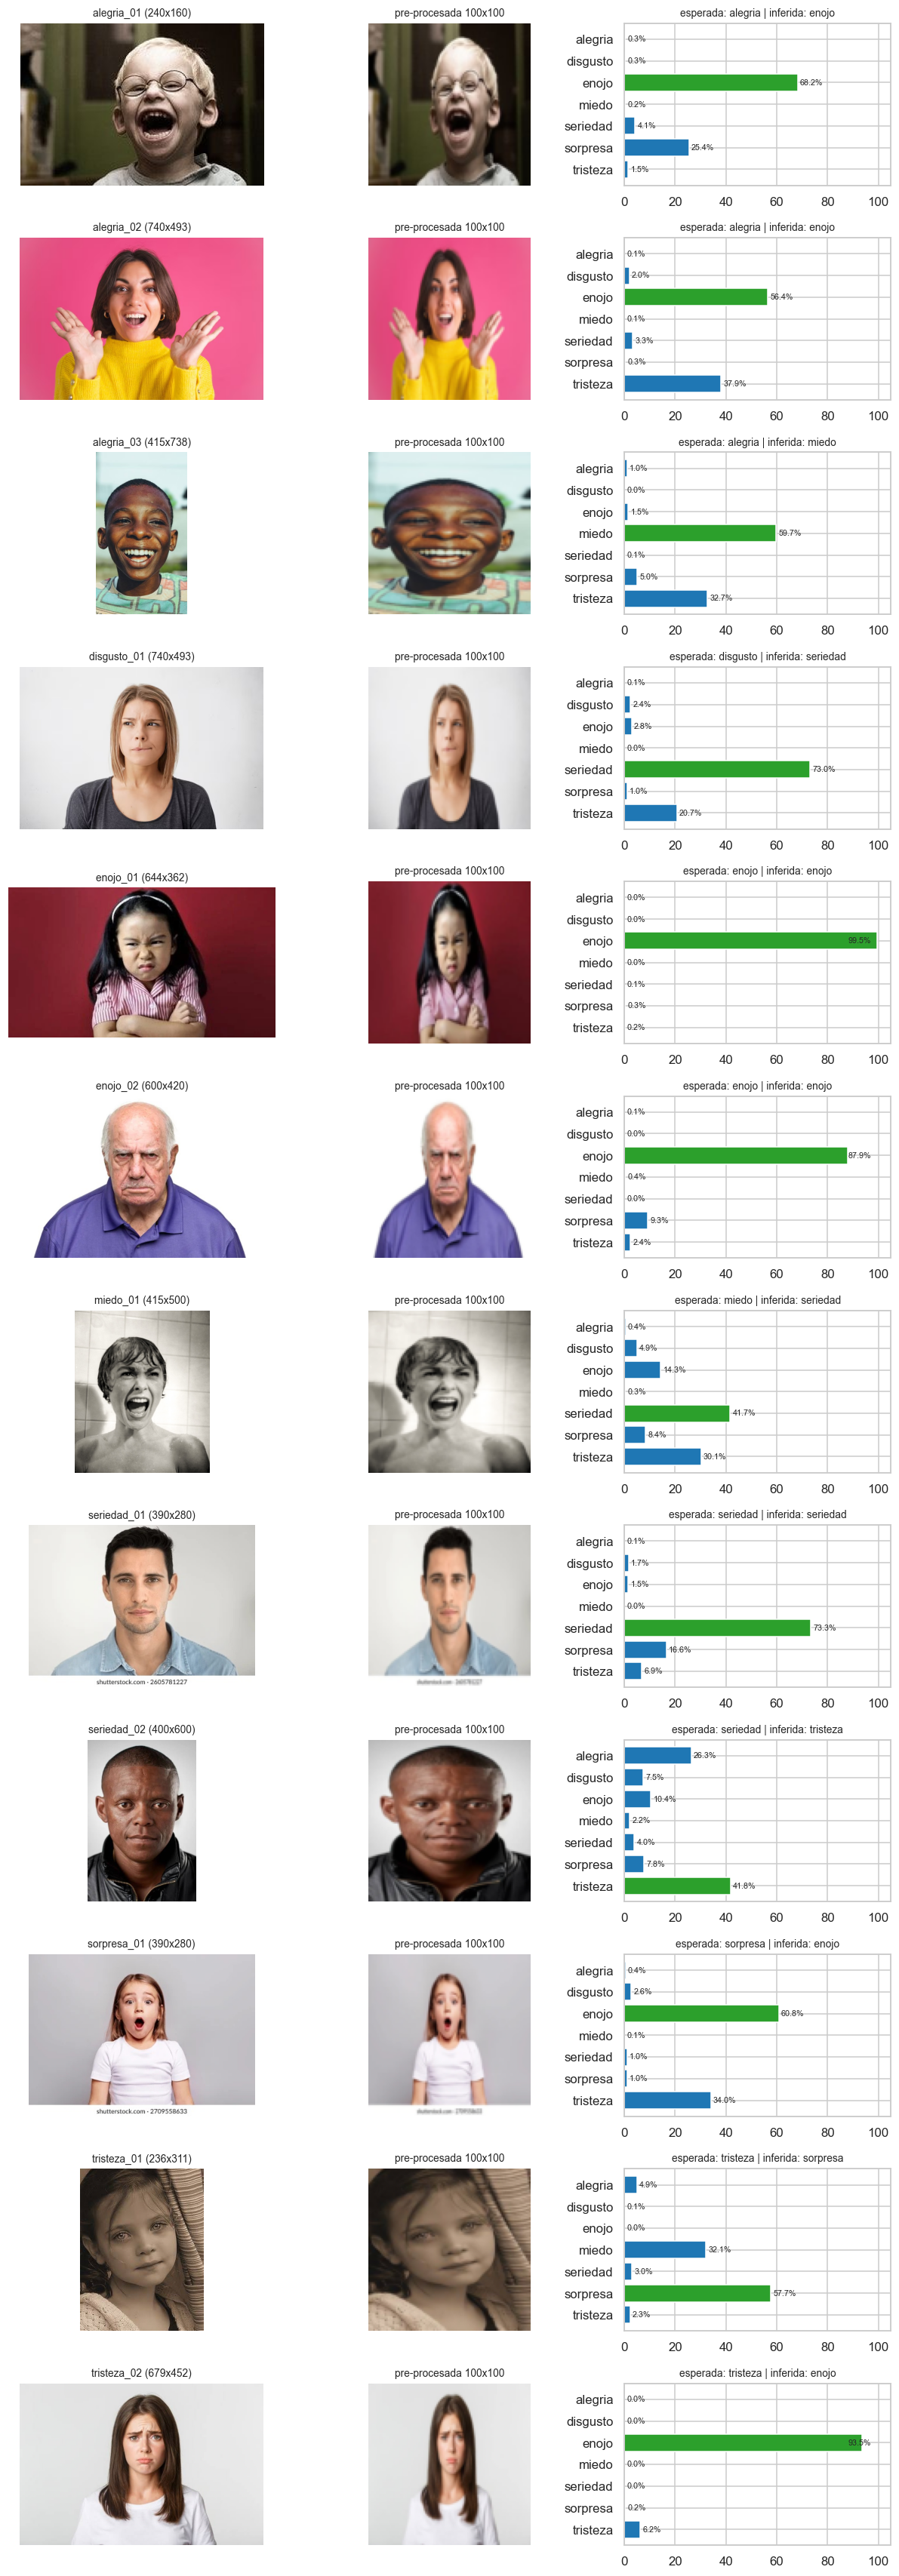

In [20]:
predicciones_p4 = []
fig, axes = plt.subplots(len(imagenes_nuevas), 3, figsize=(11, 2.6 * len(imagenes_nuevas)))
for fila, (imagen, esperada, nombre) in enumerate(imagenes_nuevas):
    tensor = preprocesar(imagen)
    scores, ganadora = predecir_emocion(modelo, tensor)
    predicciones_p4.append((esperada, ganadora, scores))
    paneles = [
        (f"{nombre} ({imagen.size[0]}x{imagen.size[1]})", imagen),
        ("pre-procesada 100x100", tensor),
    ]
    mostrar_prediccion(axes[fila], paneles, scores, esperada, ganadora)
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd

aciertos_p4 = sum(esperada == inferida for esperada, inferida, _ in predicciones_p4)
print(f"aciertos: {aciertos_p4}/{len(predicciones_p4)} ({aciertos_p4 / len(predicciones_p4) * 100:.0f}%)")

resumen_p4 = pd.DataFrame([
    {
        "imagen": nombre,
        "esperada": esperada,
        "inferida": inferida,
        "score ganador": f"{scores.max() * 100:.1f}%",
        "acierto": "si" if esperada == inferida else "no",
    }
    for (_, esperada, nombre), (_, inferida, scores) in zip(imagenes_nuevas, predicciones_p4)
]).set_index("imagen")
resumen_p4

aciertos: 3/12 (25%)


,esperada,inferida,score ganador,acierto
imagen,,,,
alegria_01,alegria,enojo,68.2%,no
alegria_02,alegria,enojo,56.4%,no
alegria_03,alegria,miedo,59.7%,no
disgusto_01,disgusto,seriedad,73.0%,no
enojo_01,enojo,enojo,99.5%,si
enojo_02,enojo,enojo,87.9%,si
miedo_01,miedo,seriedad,41.7%,no
seriedad_01,seriedad,seriedad,73.3%,si
seriedad_02,seriedad,tristeza,41.8%,no


### Conclusiones preliminares

El modelo acierta solo 3 de las 12 fotos, lejos del 80% de accuracy que tenía en validación. Y las que acierta son las dos de enojo y una de seriedad, las que ya venían como primer plano de la cara y con un encuadre parecido al del dataset.

El problema se ve en las imágenes pre-procesadas. El dataset de entrenamiento tiene caras centradas que llenan el cuadro de 100x100, mis fotos traen fondo, pelo y torso, así que después del resize la cara queda chica y deformada. Con esa entrada el modelo responde cualquier cosa, por ejemplo manda sonrisas claras de alegría hacia enojo o miedo, y con un alto score. Estas fotos están fuera de la distribución de los datos con la que se entrenó, por lo que los scores dejan de ser confiables.

En resumen el modelo no parece estar mal, por que cuando la foto se parece al dataset responde bien. Si se ve que es importante que las fotos sean similares a las que vio el modelo en entrenamieto. 

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.

### Detección y recorte de rostros

Adapto el código de la cátedra a una función para poder aplicarla a las 12 fotos. La lógica es la misma, detecta con el Haar cascade frontal de OpenCV, marca las detecciones sobre la imagen y recorta un cuadrado 1:1 centrado en el rostro. Le agrego un solo cambio, si hay más de una detección me quedo con la más grande en lugar de la primera, porque en algunas fotos el cascade también marca cuadrados chicos y el rostro real siempre es la caja más grande.

In [22]:
import cv2

CASCADE_ROSTROS = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")


def recortar_rostro(imagen, scale_factor=1.1, min_neighbors=6, min_size=(30, 30)):
    bgr = cv2.cvtColor(np.array(imagen), cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    faces = CASCADE_ROSTROS.detectMultiScale(
        gray, 
        scaleFactor=scale_factor,
        minNeighbors=min_neighbors, 
        minSize=min_size
    )

    con_box = bgr.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(con_box, (x, y), (x + w, y + h), (0, 255, 0), 2)

    recorte = None
    if len(faces) > 0:
        # con más de una detección me quedo con la más grande, que es el rostro real
        (x, y, w, h) = max(faces, key=lambda f: f[2] * f[3])
        centro_x, centro_y = x + w // 2, y + h // 2
        mitad = max(w, h) // 2
        x1, y1 = max(centro_x - mitad, 0), max(centro_y - mitad, 0)
        x2 = min(centro_x + mitad, bgr.shape[1])
        y2 = min(centro_y + mitad, bgr.shape[0])
        recorte = Image.fromarray(cv2.cvtColor(bgr[y1:y2, x1:x2], cv2.COLOR_BGR2RGB))

    return recorte, Image.fromarray(cv2.cvtColor(con_box, cv2.COLOR_BGR2RGB))

### Ajuste de los parámetros de detección

Con los valores del código de la cátedra el cascade no encuentra el rostro en una de mis 12 fotos, así que bajo `minNeighbors` a 4, que relaja la cantidad de vecinos que necesita una ventana para confirmarse como rostro. Con eso detecta en las 12 y las cajas extras que aparecen en un par de fotos las filtra el criterio de quedarme con la detección más grande. 

In [23]:
SCALE_FACTOR = 1.1
MIN_NEIGHBORS = 4
MIN_SIZE = (30, 30)

filas = []
for imagen, _, nombre in imagenes_nuevas:
    recorte, _ = recortar_rostro(imagen, SCALE_FACTOR, MIN_NEIGHBORS, MIN_SIZE)
    filas.append({
        "imagen": nombre,
        "rostro detectado": "si" if recorte is not None else "no",
        "tamano del recorte": f"{recorte.size[0]}x{recorte.size[1]}" if recorte is not None else "-",
    })
deteccion = pd.DataFrame(filas).set_index("imagen")

detectadas = (deteccion["rostro detectado"] == "si").sum()
print(f"rostros detectados: {detectadas}/{len(imagenes_nuevas)}")
deteccion

rostros detectados: 12/12


,rostro detectado,tamano del recorte
imagen,,
alegria_01,si,106x106
alegria_02,si,206x206
alegria_03,si,334x334
disgusto_01,si,170x170
enojo_01,si,144x144
enojo_02,si,192x192
miedo_01,si,226x226
seriedad_01,si,146x146
seriedad_02,si,274x274


Repito el flujo del punto 4 pero pasando por el modelo el rostro recortado en lugar de la foto entera. Muestro la original con las detecciones marcadas, el recorte 1:1, la pre-procesada y los scores.

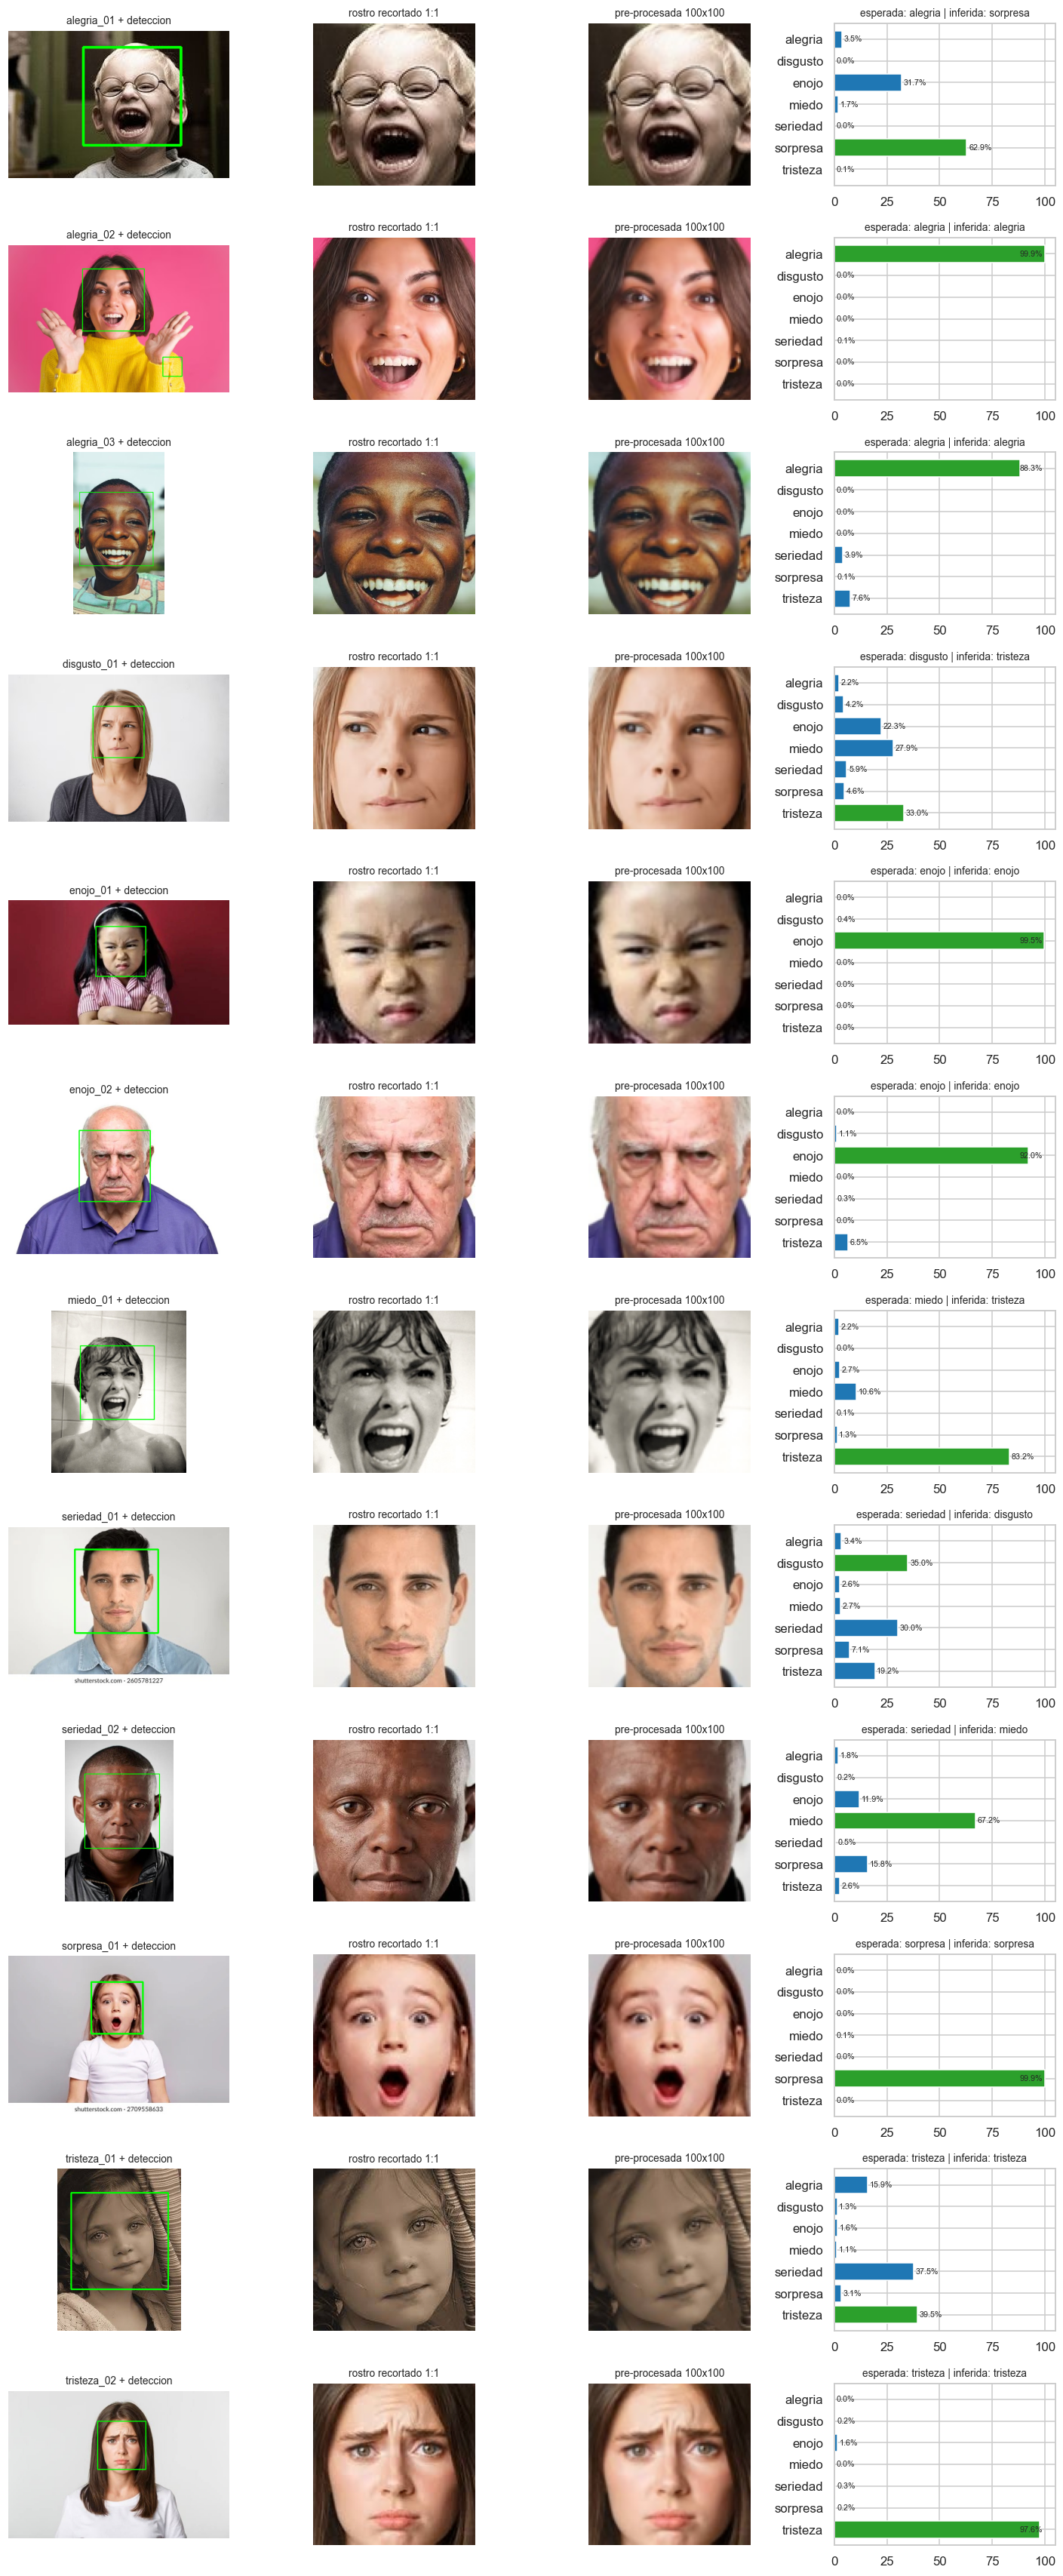

In [24]:
predicciones_p5 = []
fig, axes = plt.subplots(len(imagenes_nuevas), 4, figsize=(13, 2.6 * len(imagenes_nuevas)))
for fila, (imagen, esperada, nombre) in enumerate(imagenes_nuevas):
    recorte, con_box = recortar_rostro(imagen, SCALE_FACTOR, MIN_NEIGHBORS, MIN_SIZE)
    tensor = preprocesar(recorte)
    scores, ganadora = predecir_emocion(modelo, tensor)
    predicciones_p5.append((esperada, ganadora, scores))
    paneles = [
        (f"{nombre} + deteccion", con_box),
        ("rostro recortado 1:1", recorte),
        ("pre-procesada 100x100", tensor),
    ]
    mostrar_prediccion(axes[fila], paneles, scores, esperada, ganadora)
plt.tight_layout()
plt.show()

### Comparación con el punto 4

Armo una tabla con la clase esperada y lo que infirió el modelo en cada punto, con el score de la clase ganadora entre paréntesis, para comparar los dos flujos lado a lado.

In [25]:
filas = []
for (_, _, nombre), (esperada, inf4, sc4), (_, inf5, sc5) in zip(imagenes_nuevas, predicciones_p4, predicciones_p5):
    filas.append({
        "imagen": nombre,
        "esperada": esperada,
        "punto 4 (foto entera)": f"{inf4} ({sc4.max() * 100:.1f}%)",
        "punto 5 (rostro recortado)": f"{inf5} ({sc5.max() * 100:.1f}%)",
        "acierto p4": "si" if inf4 == esperada else "no",
        "acierto p5": "si" if inf5 == esperada else "no",
    })
comparacion = pd.DataFrame(filas).set_index("imagen")

aciertos_p5 = sum(esperada == inferida for esperada, inferida, _ in predicciones_p5)
print(f"aciertos punto 4: {aciertos_p4}/{len(predicciones_p4)} | aciertos punto 5: {aciertos_p5}/{len(predicciones_p5)}")
comparacion

aciertos punto 4: 3/12 | aciertos punto 5: 7/12


,esperada,punto 4 (foto entera),punto 5 (rostro recortado),acierto p4,acierto p5
imagen,,,,,
alegria_01,alegria,enojo (68.2%),sorpresa (62.9%),no,no
alegria_02,alegria,enojo (56.4%),alegria (99.9%),no,si
alegria_03,alegria,miedo (59.7%),alegria (88.3%),no,si
disgusto_01,disgusto,seriedad (73.0%),tristeza (33.0%),no,no
enojo_01,enojo,enojo (99.5%),enojo (99.5%),si,si
enojo_02,enojo,enojo (87.9%),enojo (92.0%),si,si
miedo_01,miedo,seriedad (41.7%),tristeza (83.2%),no,no
seriedad_01,seriedad,seriedad (73.3%),disgusto (35.0%),si,no
seriedad_02,seriedad,tristeza (41.8%),miedo (67.2%),no,no


### Análisis de errores y conclusiones finales

Con el recorte de la cara el modelo pasa de 3 a 7 aciertos sobre 12, y los aciertos ahora vienen con scores altos. Cuando la cara ocupa todo el cuadro, como en el dataset, el modelo se comporta como en validación.

Los 5 errores que quedan caen en dos grupos:

- **Mezcla de emociones:** Una risa a carcajadas con la boca bien abierta se va a sorpresa, expresión que se puede ver tanto en alegria como en sorpresa. Y ante un gesto de seriedad o de disgusto, que son similares, el modelo directamente no se decide, reparte el score entre clases.

- **Similitudes entre emociones:** Miedo se va a tristeza y seriedad se va a disgusto y miedo. Si vemos las imagenes del dataset original, hasta para un humano resultan similares. En el modelo ademas disgusto y miedo son las clases con menos imágenes de entrenamiento y peor F1 en validación.

En resumen, el modelo funciona mejor con caras frontales centradas que ocupan todo el cuadro, como las del dataset. Con las fotos crudas acertó el 3/12 (25%) y con el recorte por Haar cascade el 7/12 (58%), y los errores que quedan son de las clases débiles del dataset o de expresiones ambiguas. Para fotos reales el pipeline tiene que ser siempre detección de rostro, recorte y recién ahí la CNN, y si los scores salen repartidos es señal de que la foto es ambigua.

## Apéndice: prueba en vivo con webcam

Veamos que pasa en vivo con la webcam. El algoritmo detecta el rostro con el Haar cascade y los mismos parámetros del punto 5, se recorta el cuadrado 1:1 y el modelo clasifica reusando las funciones de preprocesar y predecir_emocion.

La celda detecta dónde está corriendo y elige el modo:

- **En local:** abre una ventana de OpenCV con video en vivo, dibuja la caja, la emoción ganadora y su score sobre cada frame, y se cierra apretando q. La primera vez el sistema operativo pide permiso de cámara para la terminal o el IDE.
- **En Colab:** OpenCV no llega a la webcam porque el kernel corre en un servidor remoto, así que se usa el snippet de cámara de Colab, un botón de captura que saca una foto desde el navegador. Con esa foto se muestra la misma fila del punto 5, captura con detección, recorte, pre-procesada y scores. El navegador pide permiso de cámara al ejecutarla.

In [26]:
import sys
import io
from base64 import b64decode

if "google.colab" in sys.modules:
    from google.colab.output import eval_js
    from IPython.display import Javascript, display


def demo_webcam_local(camara=0):
    captura = cv2.VideoCapture(camara)
    if not captura.isOpened():
        print("no se pudo abrir la webcam, revisar permisos de camara")
        return
    print("demo en vivo, apretar q sobre la ventana para salir")
    try:
        while True:
            ok, frame = captura.read()
            if not ok:
                break
            # espejado horizontal para que se vea como en meet, al modelo no le
            # afecta porque entrenó con flips horizontales como augmentation
            frame = cv2.flip(frame, 1)
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            # minSize más grande que en el punto 5 porque en webcam la cara está cerca,
            # así se evitan detecciones espurias chicas en el fondo
            faces = CASCADE_ROSTROS.detectMultiScale(
                gray,
                scaleFactor=SCALE_FACTOR,
                minNeighbors=MIN_NEIGHBORS,
                minSize=(80, 80)
            )

            if len(faces) > 0:
                (x, y, w, h) = max(faces, key=lambda f: f[2] * f[3])
                centro_x, centro_y = x + w // 2, y + h // 2
                mitad = max(w, h) // 2
                x1, y1 = max(centro_x - mitad, 0), max(centro_y - mitad, 0)
                x2 = min(centro_x + mitad, frame.shape[1])
                y2 = min(centro_y + mitad, frame.shape[0])
                rostro = Image.fromarray(cv2.cvtColor(frame[y1:y2, x1:x2], cv2.COLOR_BGR2RGB))
                scores, ganadora = predecir_emocion(modelo, preprocesar(rostro))
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(
                    frame, f"{ganadora} {scores.max() * 100:.0f}%", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2
                )
            cv2.imshow("clasificador de emociones (q para salir)", frame)
            if cv2.waitKey(1) & 0xFF == ord("q"):
                break
    finally:
        captura.release()
        cv2.destroyAllWindows()
        for _ in range(5):
            cv2.waitKey(1)


def foto_desde_colab(calidad=0.8):
    # snippet de camara de Colab, prende la webcam del navegador y devuelve la captura como PIL
    js = Javascript("""
      async function tomarFoto(calidad) {
        const div = document.createElement('div');
        const boton = document.createElement('button');
        boton.textContent = 'capturar';
        div.appendChild(boton);
        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
        await new Promise((resolve) => boton.onclick = resolve);
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getVideoTracks()[0].stop();
        div.remove();
        return canvas.toDataURL('image/jpeg', calidad);
      }
    """)
    display(js)
    datos = eval_js(f"tomarFoto({calidad})")
    return Image.open(io.BytesIO(b64decode(datos.split(",")[1]))).convert("RGB")


def demo_webcam_colab():
    foto = foto_desde_colab()
    recorte, con_box = recortar_rostro(foto, SCALE_FACTOR, MIN_NEIGHBORS, MIN_SIZE)
    if recorte is None:
        print("no se detectó rostro en la captura, probar de nuevo")
        return
    tensor = preprocesar(recorte)
    scores, ganadora = predecir_emocion(modelo, tensor)
    fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
    paneles = [
        ("captura + deteccion", con_box),
        ("rostro recortado 1:1", recorte),
        ("pre-procesada 100x100", tensor),
    ]
    mostrar_prediccion(axes, paneles, scores, "?", ganadora)
    plt.tight_layout()
    plt.show()

In [ ]:
if "google.colab" in sys.modules:
    demo_webcam_colab()
else:
    demo_webcam_local()

demo en vivo, apretar q sobre la ventana para salir


: 